# Library

In [50]:
from keras.src.callbacks import CSVLogger, TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.src.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.applications.inception_v3 import InceptionV3
from sklearn.model_selection import train_test_split
from keras.src.metrics import Precision, Recall
from keras.src.utils import to_categorical
from keras.src.regularizers import L2
from keras.src.optimizers import Adam
import plotly.graph_objects as go
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from collections import Counter
from keras import Sequential
import plotly.express as px
import seaborn as sns
import numpy as np
import warnings
import time
import glob
import cv2
import os

# PATH & Variable & Constants

In [51]:
warnings.filterwarnings('ignore')

VERSION = "v23"
BASE_DIR = "output"
DATASET_DIR = "dataset"
TRAIN_PATH = os.path.join(DATASET_DIR, "training")
PLOT_SAVE_DIR = os.path.join(BASE_DIR, "plot", VERSION)
LOG_DIR = os.path.join(BASE_DIR, "log", VERSION)
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "model", VERSION, "train.keras")
HISTORY_PATH = os.path.join(BASE_DIR, "model", VERSION, "train_history.npy")
CSV_LOGGER_PATH = os.path.join(LOG_DIR, "training_log.csv")

IMAGE_SIZE = (299, 299)
INPUT_SHAPE = (299, 299, 3)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
FINE_TUNE_EPOCHS = 30
FINE_TUNE_LR = 1e-4

TOTAL_SIZE = 4000
TRAIN_SIZE = int(0.8 * TOTAL_SIZE)
VAL_SIZE = int(0.1 * TOTAL_SIZE)
TEST_SIZE = int(0.1 * TOTAL_SIZE)

CLASS_NAMES = sorted([os.path.basename(d) for d in glob.glob(os.path.join(TRAIN_PATH, "*")) if os.path.isdir(d)])
NB_CLASSES = len(CLASS_NAMES)
LABEL_MAPPING = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

print(f"Model Version: {VERSION}")
print(f"Train Path: {TRAIN_PATH}")
print(f"{NB_CLASSES} Classes: {CLASS_NAMES}")

for directory in [PLOT_SAVE_DIR, LOG_DIR, os.path.dirname(MODEL_SAVE_PATH)]:
    os.makedirs(directory, exist_ok=True)

Model Version: v23
Train Path: dataset/training
4 Classes: ['alcohol', 'blood', 'sexual', 'traffic_accident']


# Load Data

In [52]:
def load_data(dataset, label_mapping, image_size=IMAGE_SIZE):
    images, labels = [], []
    for folder in os.listdir(dataset):
        folder_path = os.path.join(dataset, folder)
        if folder not in label_mapping or not os.path.isdir(folder_path):
            continue

        label = label_mapping[folder]
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(label)
    return np.array(images, dtype='float32'), np.array(labels, dtype='int')

# Execute images and labels

In [53]:
images, labels = load_data(TRAIN_PATH, LABEL_MAPPING)
images, labels = shuffle(images, labels, random_state=42)

In [54]:
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, stratify=labels, test_size=0.2, random_state=42)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, stratify=temp_labels, test_size=0.5, random_state=42)

In [55]:
train_labels = to_categorical(train_labels, num_classes=NB_CLASSES)
val_labels = to_categorical(val_labels, num_classes=NB_CLASSES)
test_labels = to_categorical(test_labels, num_classes=NB_CLASSES)

# Data Augmentation

In [56]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Generators
train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)


# Visualize dataset

In [57]:
train_labels_int = np.argmax(train_labels, axis=1)

class_counts = Counter(train_labels_int.tolist())

class_labels = [CLASS_NAMES[label] for label in class_counts.keys()]
counts = list(class_counts.values())

# Plot Class Distribution
fig = px.bar(
    x=class_labels,
    y=counts,
    template='plotly_dark',
    color=class_labels,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'},
    text=counts
)

fig.update_layout(
    xaxis_title='Class Label',
    yaxis_title='Count of Images',
    showlegend=False
)

fig.show()

In [58]:
train_labels_int = np.argmax(train_labels, axis=1)
val_labels_int = np.argmax(val_labels, axis=1)
test_labels_int = np.argmax(test_labels, axis=1)

train_counter = Counter(train_labels_int)
val_counter = Counter(val_labels_int)
test_counter = Counter(test_labels_int)

train_counts = [train_counter.get(i, 0) for i in range(NB_CLASSES)]
val_counts = [val_counter.get(i, 0) for i in range(NB_CLASSES)]
test_counts = [test_counter.get(i, 0) for i in range(NB_CLASSES)]

fig = go.Figure()

# Train Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=train_counts,
    name='Train',
    marker=dict(color='blue'),
    text=train_counts,
    textposition='auto'
))

# Validation Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=val_counts,
    name='Validation',
    marker=dict(color='green'),
    text=val_counts,
    textposition='auto'
))

# Test Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=test_counts,
    name='Test',
    marker=dict(color='red'),
    text=test_counts,
    textposition='auto'
))

# Layout Configuration
fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark",
    xaxis=dict(tickangle=-45)
)

fig.show()

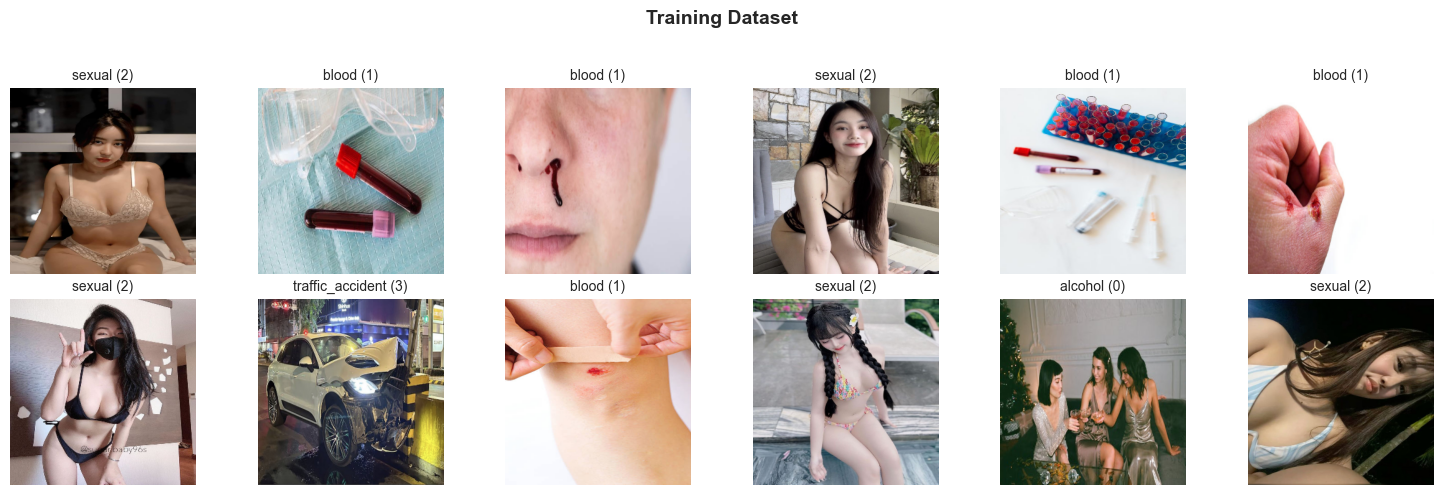

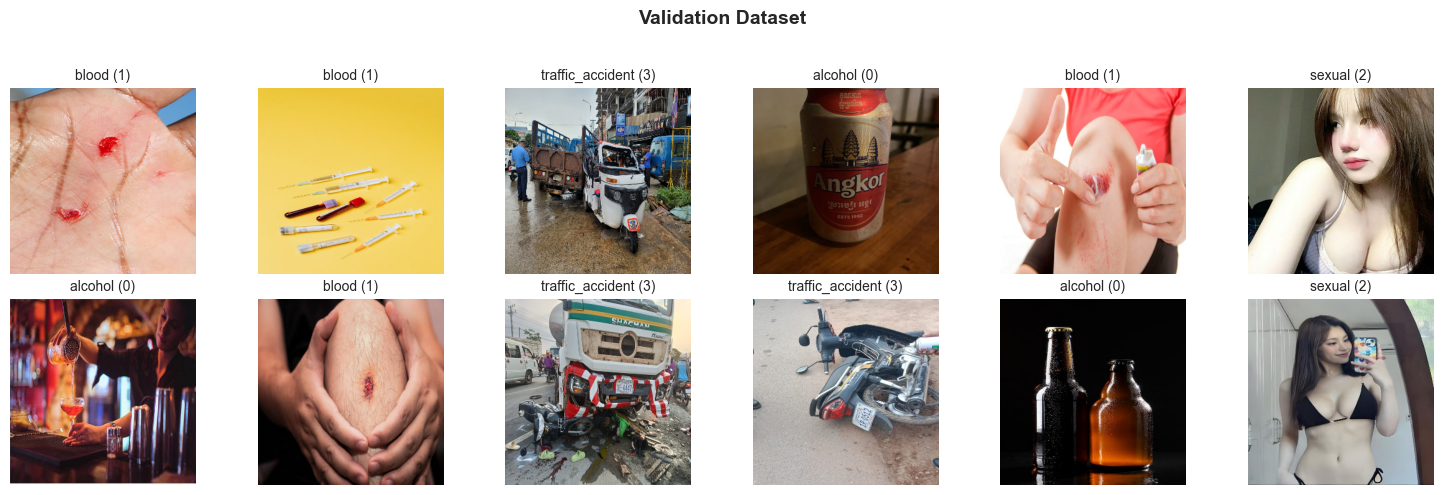

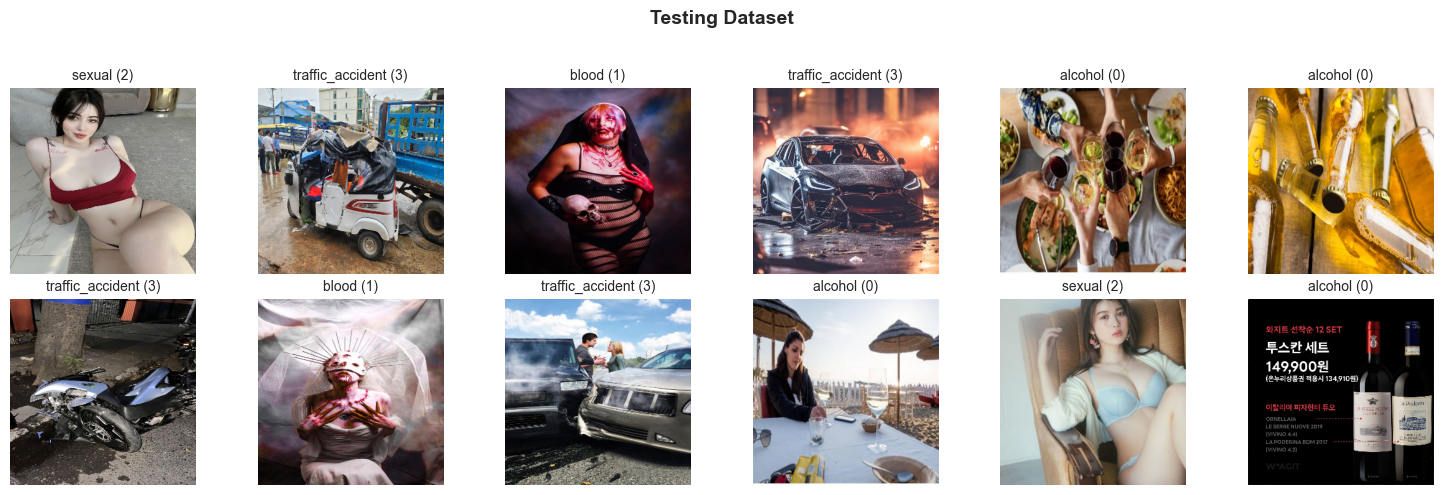

In [59]:
def display_dataset(class_names, images, labels, dataset_type, num_images=12):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    cols = 6
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(15, 15 * rows / cols), facecolor="none")
    plt.suptitle(f"{dataset_type} Dataset", fontsize=14, fontweight='bold')

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = labels[idx]

        if labels.ndim > 1:
            label = np.argmax(label)
        class_name = class_names[label]

        if image.dtype != np.uint8:
            image = image.astype(np.uint8)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"{class_name} ({label})", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


# Display Training Dataset
display_dataset(CLASS_NAMES, train_images, train_labels, "Training")

# Display Validation Dataset
display_dataset(CLASS_NAMES, val_images, val_labels, "Validation")

# Display Testing Dataset
display_dataset(CLASS_NAMES, test_images, test_labels, "Testing")

# Model architecture

In [60]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=L2(l2=0.01)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=L2(l2=0.0)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NB_CLASSES, activation='softmax')
])

optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_382         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_383         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,362,276 (85.31 MB)

 Trainable params: 558,724 (2.13 MB)

 Non-trainable params: 21,803,552 (83.17 MB)

# Compile the model

Starting Training...
Epoch 1/50

Epoch 1: val_loss improved from inf to 2.70933, saving model to output/model/v23/train.keras
100/100 - 145s - 1s/step - accuracy: 0.8784 - loss: 3.9428 - precision: 0.8997 - recall: 0.8578 - val_accuracy: 0.9625 - val_loss: 2.7093 - val_precision: 0.9721 - val_recall: 0.9575 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 2.70933 to 1.44164, saving model to output/model/v23/train.keras
100/100 - 145s - 1s/step - accuracy: 0.9291 - loss: 2.0869 - precision: 0.9332 - recall: 0.9216 - val_accuracy: 0.9600 - val_loss: 1.4416 - val_precision: 0.9672 - val_recall: 0.9575 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.44164 to 0.92156, saving model to output/model/v23/train.keras
100/100 - 143s - 1s/step - accuracy: 0.9409 - loss: 1.1944 - precision: 0.9451 - recall: 0.9316 - val_accuracy: 0.9350 - val_loss: 0.9216 - val_precision: 0.9394 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss impro

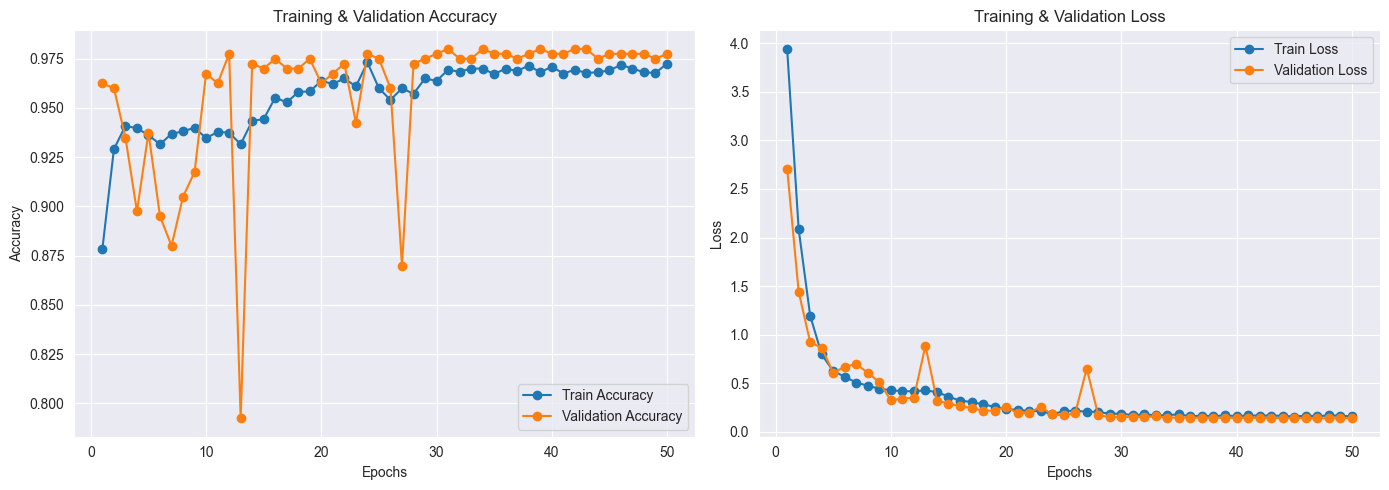

Training history plot saved at: output/plot/v23/training_history.png


In [61]:
# Callbacks
callbacks = [
    CSVLogger(CSV_LOGGER_PATH, append=False),
    TensorBoard(log_dir=LOG_DIR, histogram_freq=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]


# Plotting function
def plot_training_history(history, phase_name="training"):
    epochs = range(1, len(history.history.get('accuracy', [])) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history and 'val_accuracy' in history.history:
        plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
        plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{phase_name} & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    if 'loss' in history.history and 'val_loss' in history.history:
        plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
        plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{phase_name} & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    plot_path = os.path.join(PLOT_SAVE_DIR, f"{phase_name.lower()}_history.png")
    plt.savefig(plot_path)
    plt.show()
    print(f"{phase_name} history plot saved at: {plot_path}")


# Phase 1: Initial Training (Feature Extraction)
print("Starting Training...")
start_time = time.time()

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

print(f"Training time (sec): {time.time() - start_time}")
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)
print("Training Complete!")
plot_training_history(history, phase_name="Training")

Starting Fine-Tuning...
Epoch 1/30

Epoch 1: val_loss did not improve from 0.13892
100/100 - 351s - 4s/step - accuracy: 0.9250 - loss: 0.3096 - precision: 0.9274 - recall: 0.9222 - val_accuracy: 0.9150 - val_loss: 0.4800 - val_precision: 0.9196 - val_recall: 0.9150 - learning_rate: 1.0000e-04
Epoch 2/30

Epoch 2: val_loss improved from 0.13892 to 0.12948, saving model to output/model/v23/train.keras
100/100 - 351s - 4s/step - accuracy: 0.9603 - loss: 0.1748 - precision: 0.9635 - recall: 0.9581 - val_accuracy: 0.9800 - val_loss: 0.1295 - val_precision: 0.9799 - val_recall: 0.9775 - learning_rate: 1.0000e-04
Epoch 3/30

Epoch 3: val_loss did not improve from 0.12948
100/100 - 343s - 3s/step - accuracy: 0.9741 - loss: 0.1463 - precision: 0.9749 - recall: 0.9725 - val_accuracy: 0.9750 - val_loss: 0.1488 - val_precision: 0.9774 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 4/30

Epoch 4: val_loss improved from 0.12948 to 0.11245, saving model to output/model/v23/train.keras
100/100

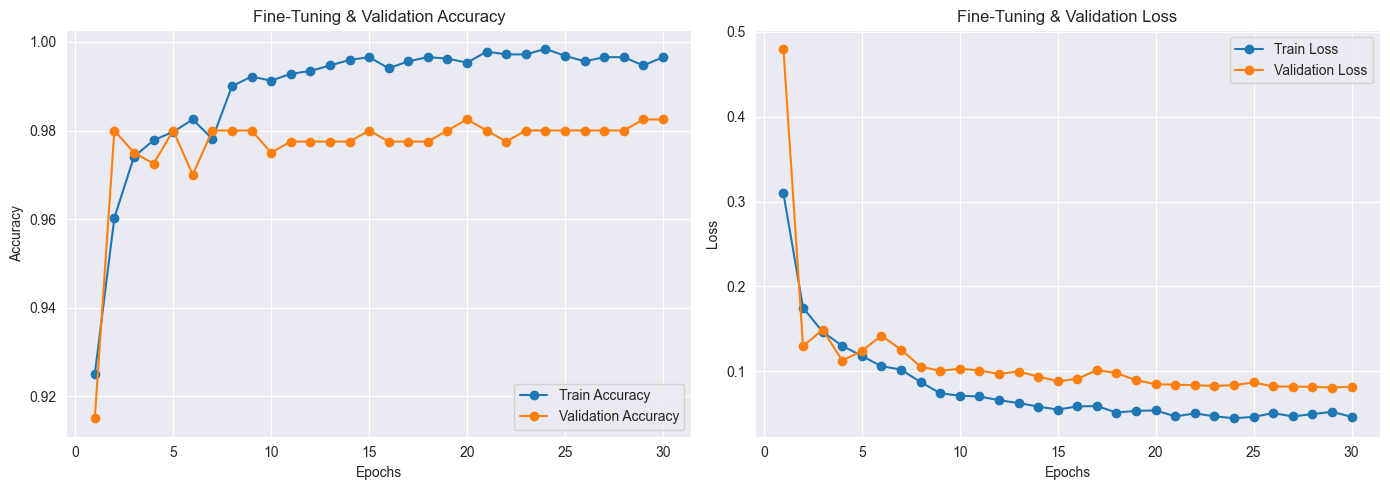

Fine-Tuning history plot saved at: output/plot/v23/fine-tuning_history.png


In [62]:
# Phase 2: Fine-Tuning
print("Starting Fine-Tuning...")
start_time = time.time()

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

callbacks[0] = CSVLogger(CSV_LOGGER_PATH, append=True)

fine_tune_history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=2
)

print(f"Fine-tuning time (sec): {time.time() - start_time}")

fine_tuned_model_path = MODEL_SAVE_PATH.replace(".keras", "_fine_tuned.keras")
fine_tuned_history_path = HISTORY_PATH.replace(".npy", "_fine_tuned.npy")
model.save(fine_tuned_model_path)
np.save(fine_tuned_history_path, fine_tune_history.history)

print("Fine-Tuning Complete!")
plot_training_history(fine_tune_history, phase_name="Fine-Tuning")

# Evaluate the model

In [63]:
# Confusion matrix 
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plot_path = os.path.join(PLOT_SAVE_DIR, "confusion_matrix.png")
    plt.savefig(plot_path)
    plt.show()
    print(f"✅ Confusion matrix saved at: {plot_path}")

Evaluating on Test Set...
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

📊 Classification Report (dict):
 {'alcohol': {'precision': 0.99, 'recall': 0.99, 'f1-score': 0.99, 'support': 100.0}, 'blood': {'precision': 0.9702970297029703, 'recall': 0.98, 'f1-score': 0.9751243781094527, 'support': 100.0}, 'sexual': {'precision': 0.98989898989899, 'recall': 0.98, 'f1-score': 0.9849246231155779, 'support': 100.0}, 'traffic_accident': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 100.0}, 'accuracy': 0.9875, 'macro avg': {'precision': 0.98754900490049, 'recall': 0.9875, 'f1-score': 0.9875122503062577, 'support': 400.0}, 'weighted avg': {'precision': 0.9875490049004901, 'recall': 0.9875, 'f1-score': 0.9875122503062577, 'support': 400.0}}
✅ Classification report saved at: output/log/v23/classification_report.txt


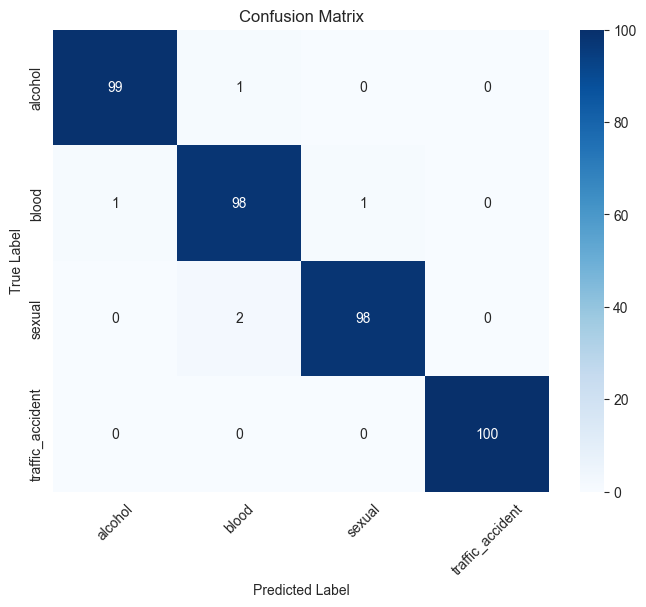

✅ Confusion matrix saved at: output/plot/v23/confusion_matrix.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9878 - loss: 0.0786 - precision: 0.9878 - recall: 0.9878
Test Accuracy: 0.9875, Precision: 0.9875, Recall: 0.9875


In [64]:
print("Evaluating on Test Set...")
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Classification report
report_dict = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES, output_dict=True)
print("\n📊 Classification Report (dict):\n", report_dict)

report_str = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES)
with open(os.path.join(LOG_DIR, "classification_report.txt"), 'w') as f: f.write(report_str)
print(f"✅ Classification report saved at: {os.path.join(LOG_DIR, 'classification_report.txt')}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plot_confusion_matrix(cm, CLASS_NAMES)

# Test metrics
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")

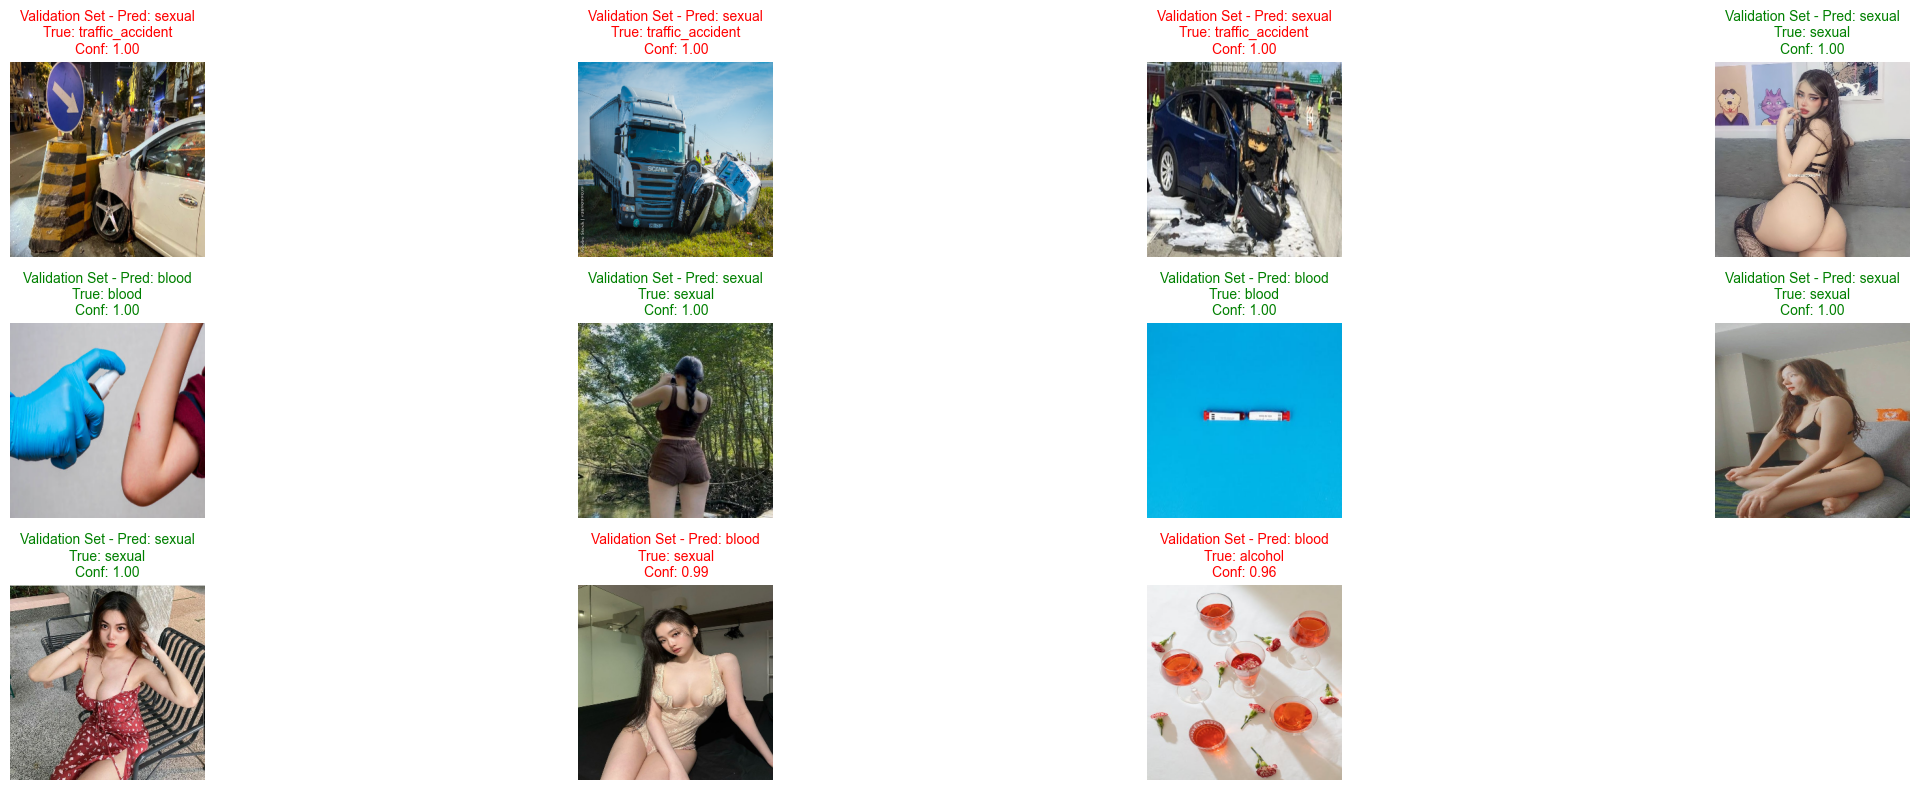

Sample predictions saved at: output/plot/v23/validation_sample_predictions.png


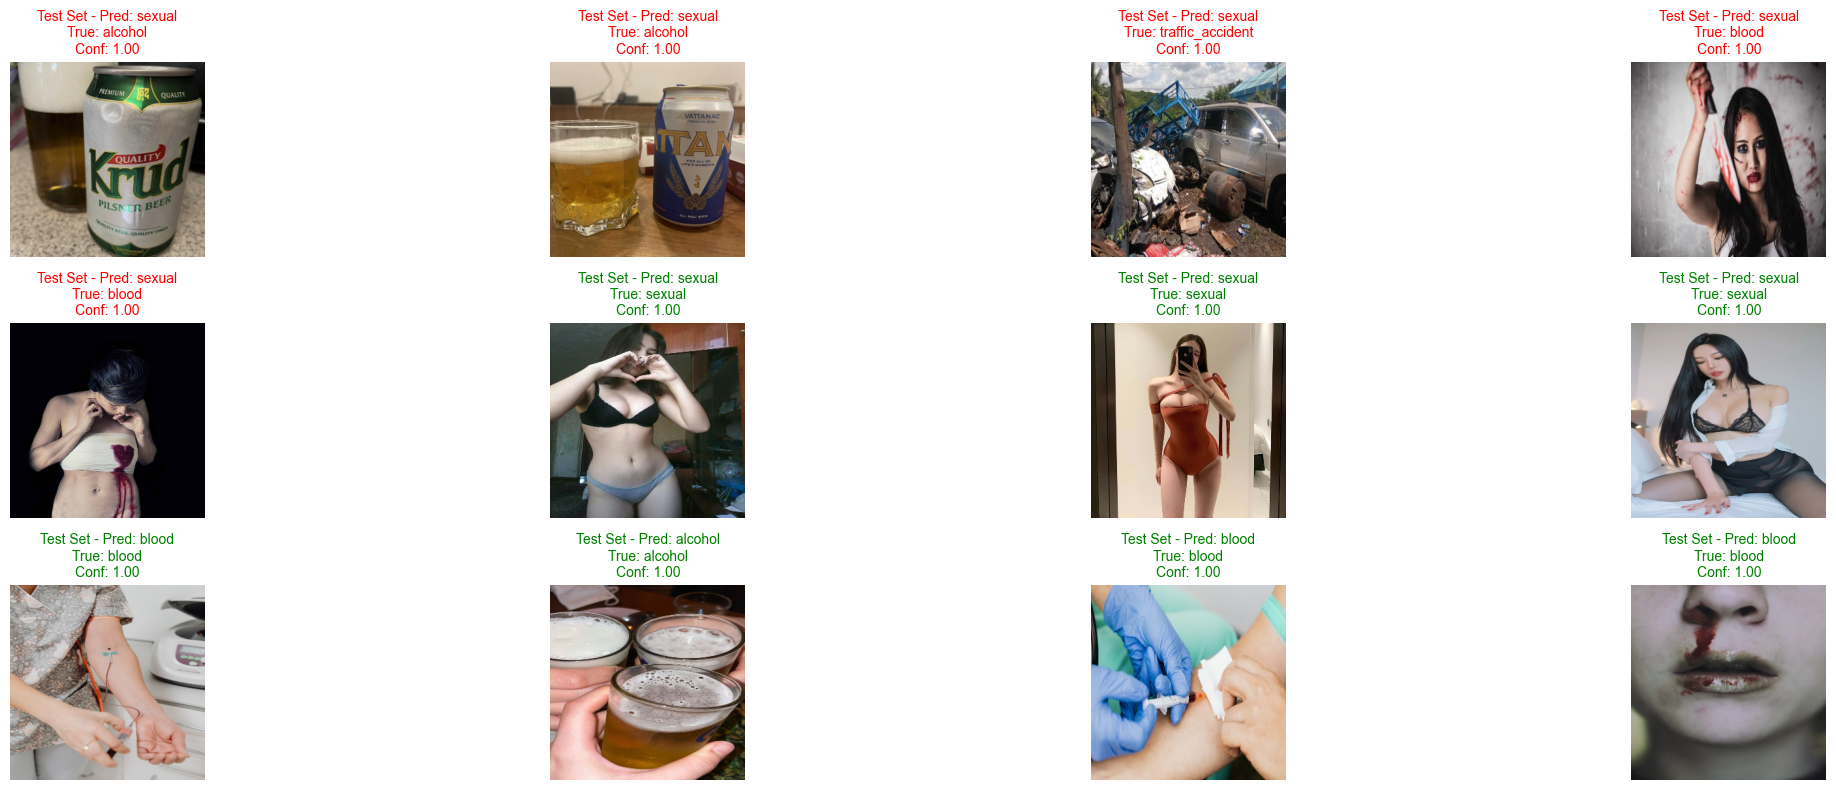

Sample predictions saved at: output/plot/v23/test_sample_predictions.png


In [72]:
def display_sample_predictions(model, class_names, images, labels, set_name="Sample", num_images=12,
                               confidence_threshold=0.8):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(num_images * 2, 8))

    misclassified = []
    correct = []

    for idx in random_indices:
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input, verbose=0)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        if confidence >= confidence_threshold:
            if predicted_label == true_label:
                correct.append((idx, confidence))
            else:
                misclassified.append((idx, confidence))

    sorted_indices = [i[0] for i in sorted(misclassified + correct, key=lambda x: x[1], reverse=True)]

    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols

    for i, idx in enumerate(sorted_indices[:num_images]):
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input, verbose=0)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.astype(np.uint8))
        plt.axis('off')

        title_color = "green" if predicted_label == true_label else "red"
        plt.title(f"{set_name} Set - Pred: {class_names[predicted_label]}\n"
                  f"True: {class_names[true_label]}\n"
                  f"Conf: {confidence:.2f}",
                  fontsize=10, color=title_color)

    plt.tight_layout()
    save_path = os.path.join(PLOT_SAVE_DIR, f"{set_name.lower()}_sample_predictions.png")
    plt.savefig(save_path)
    plt.show()
    print(f"Sample predictions saved at: {save_path}")


display_sample_predictions(model, CLASS_NAMES, val_images, val_labels, set_name="Validation")
display_sample_predictions(model, CLASS_NAMES, test_images, test_labels, set_name="Test")